In [3]:
import pandas as pd

df = pd.read_csv('../data/bikes_raw.csv')
df.head()

,bike_name,price,city,kms_driven,owner,age,power,brand
0,TVS Star City Plus Dual Tone 110cc,35000.0,Ahmedabad,17654.0,First Owner,3.0,110.0,TVS
1,Royal Enfield Classic 350cc,119900.0,Delhi,11000.0,First Owner,4.0,350.0,Royal Enfield
2,Triumph Daytona 675R,600000.0,Delhi,110.0,First Owner,8.0,675.0,Triumph
3,TVS Apache RTR 180cc,65000.0,Bangalore,16329.0,First Owner,4.0,180.0,TVS
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000.0,Bangalore,10000.0,First Owner,3.0,150.0,Yamaha


In [4]:
print(df.shape)
print(df.columns.tolist())
df.info()

(32648, 8)
['bike_name', 'price', 'city', 'kms_driven', 'owner', 'age', 'power', 'brand']
<class 'pandas.DataFrame'>
RangeIndex: 32648 entries, 0 to 32647
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   32648 non-null  str    
 1   price       32648 non-null  float64
 2   city        32648 non-null  str    
 3   kms_driven  32648 non-null  float64
 4   owner       32648 non-null  str    
 5   age         32648 non-null  float64
 6   power       32648 non-null  float64
 7   brand       32648 non-null  str    
dtypes: float64(4), str(4)
memory usage: 2.0 MB


In [5]:
print("Duplicate rows:", df.duplicated().sum())
df.describe()

Duplicate rows: 25324


,price,kms_driven,age,power
count,3.264800e+04,32648.000000,32648.000000,32648.000000
mean,6.829542e+04,26344.625184,8.048211,213.511302
std,9.071860e+04,22208.527695,4.031700,134.428868
min,4.400000e+03,1.000000,1.000000,100.000000
25%,2.500000e+04,12000.000000,5.000000,150.000000
50%,4.300000e+04,20373.000000,7.000000,150.000000
75%,8.000000e+04,35000.000000,10.000000,220.000000
max,1.900000e+06,750000.000000,63.000000,1800.000000


In [7]:
df = df.drop_duplicates()
print(df.shape)

(7324, 8)


In [8]:
print(df[df['age'] > 30][['bike_name', 'age', 'price', 'kms_driven']])
print(df[df['kms_driven'] > 200000][['bike_name', 'age', 'kms_driven', 'price']])

                          bike_name   age     price  kms_driven
334     Royal Enfield Bullet 350 cc  39.0  125000.0     16500.0
1519              Rajdoot GTX 175cc  41.0   75000.0       500.0
2146    Royal Enfield‎ Bullet 350cc  37.0   85990.0     19000.0
2978    Royal Enfield‎ Bullet 350cc  43.0   95000.0     50000.0
2980    Royal Enfield‎ Bullet 350cc  43.0  135000.0     85000.0
5017            Yezdi Classic 250cc  39.0   68000.0        23.0
5216    Royal Enfield‎ Bullet 350cc  37.0  140000.0     99999.0
5866    Royal Enfield‎ Bullet 350cc  39.0  115000.0       500.0
6685    Royal Enfield‎ Bullet 350cc  38.0  120000.0      8000.0
6689    Royal Enfield‎ Bullet 350cc  63.0   70000.0     32000.0
7467  Ideal Jawa Yezdi CL-II 250 cc  41.0  100000.0     80000.0
7860    Royal Enfield‎ Bullet 350cc  34.0   65000.0     14101.0
8320    Royal Enfield‎ Bullet 350cc  31.0   90000.0     26000.0
                               bike_name   age  kms_driven     price
50                       Yamaha FZ 

In [9]:
df['km_per_year'] = df['kms_driven'] / df['age']
print(df[df['km_per_year'] > 50000][['bike_name', 'age', 'kms_driven', 'km_per_year']])

                        bike_name   age  kms_driven  km_per_year
5670        Honda CBR 250R Repsol   4.0    233011.0     58252.75
7311         TVS Apache RTR 180cc   2.0    207102.0    103551.00
7603             Yamaha SZS 150cc   5.0    566931.0    113386.20
7633      Hero Splendor Pro 100cc  10.0    750000.0     75000.00
8345  Royal Enfield Classic 350cc   5.0    286055.0     57211.00
9160         Honda CB Shine 125cc  10.0    654984.0     65498.40


In [10]:
df = df[df['km_per_year'] <= 50000]
print(df.shape)

(7318, 9)


In [11]:
df = df.drop('km_per_year', axis=1)

In [13]:
df.shape

(7318, 8)

In [14]:
print(df['brand'].unique())
print(df['city'].nunique())
print(df['owner'].unique())

<StringArray>
[            'TVS',   'Royal Enfield',         'Triumph',          'Yamaha',
           'Honda',            'Hero',           'Bajaj',          'Suzuki',
         'Benelli',             'KTM',        'Mahindra',        'Kawasaki',
          'Ducati',         'Hyosung', 'Harley-Davidson',            'Jawa',
             'BMW',          'Indian',         'Rajdoot',             'LML',
           'Yezdi',              'MV',           'Ideal']
Length: 23, dtype: str
443
<StringArray>
['First Owner', 'Second Owner', 'Third Owner', 'Fourth Owner Or More']
Length: 4, dtype: str


In [15]:
print(df['bike_name'].nunique())
print(df['bike_name'].sample(20).tolist())

470
['Honda CB Trigger 150cc', 'Bajaj Discover 135cc', 'Bajaj Discover 125ST', 'Hyosung GT250R', 'Bajaj Pulsar 150cc', 'Royal Enfield Classic 350cc', 'Yamaha FZs 150cc', 'Royal Enfield Classic 350cc', 'Bajaj Discover 125cc', 'Bajaj Pulsar 180cc', 'KTM Duke 390cc', 'Kawasaki ER-6n 650cc', 'Honda Dream Yuga 110cc', 'KTM RC 200cc', 'Bajaj Pulsar 180cc', 'Hero Passion 100cc', 'Honda CBR 150R 150cc', 'Bajaj CT 100 100cc', 'Royal Enfield Bullet Twinspark 500cc', 'Royal Enfield Bullet Electra 350cc']


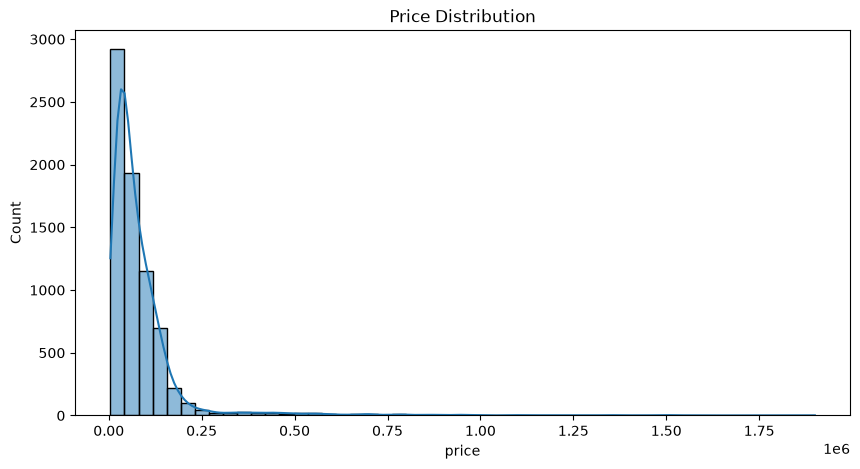

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.show()

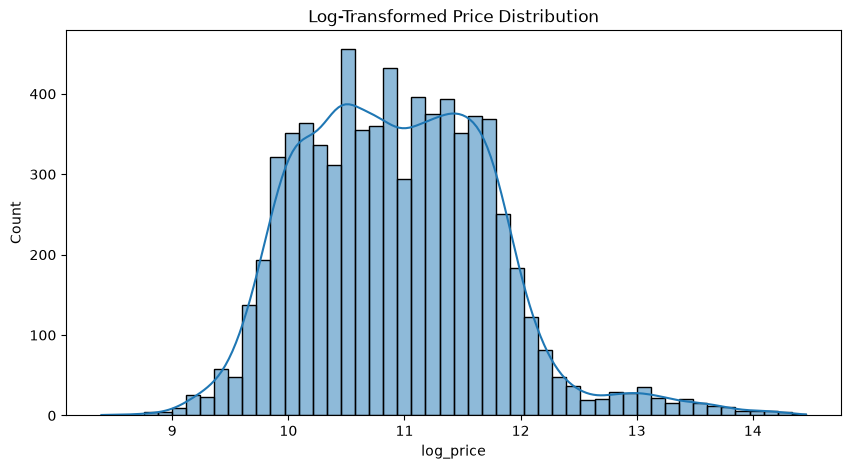

In [17]:
import numpy as np

df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(10,5))
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title('Log-Transformed Price Distribution')
plt.show()